In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats.mstats import winsorize

In [2]:
data=pd.read_csv('pubg.csv')

In [3]:
data.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


In [4]:
data.tail()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
4446961,afff7f652dbc10,d238e426f50de7,18492834ce5635,0,0,0.00,0,0,0,74,...,0,1292.0,0,0.000,0,0,1019.0,3,1507,0.1786
4446962,f4197cf374e6c0,408cdb5c46b2ac,ee854b837376d9,0,1,44.15,0,0,0,69,...,0,0.0,0,0.000,0,0,81.7,6,0,0.2935
4446963,e1948b1295c88a,e26ac84bdf7cef,6d0cd12784f1ab,0,0,59.06,0,0,0,66,...,0,0.0,0,2.184,0,0,788.7,4,0,0.4815
4446964,cc032cdd73b7ac,c2223f35411394,c9c701d0ad758a,0,4,180.40,1,1,2,11,...,2,0.0,0,0.000,0,0,2748.0,8,0,0.8000
4446965,0d8e7ed728b6fd,8c74f72fedf5ff,62a16aabcc095c,0,2,268.00,0,0,1,18,...,0,1369.0,0,0.000,0,0,1244.0,5,0,0.5464


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        object 
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints   

In [6]:
data.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,...,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446965e+06
mean,2.338149e-01,1.106908e+00,1.307171e+02,6.578755e-01,2.268196e-01,1.370147e+00,4.759935e+01,5.050060e+02,9.247833e-01,5.439551e-01,...,1.646590e-01,6.061157e+02,3.496091e-03,4.509322e+00,2.386841e-02,7.918208e-03,1.154218e+03,3.660488e+00,6.064601e+02,4.728216e-01
std,5.885731e-01,1.715794e+00,1.707806e+02,1.145743e+00,6.021553e-01,2.679982e+00,2.746294e+01,6.275049e+02,1.558445e+00,7.109721e-01,...,4.721671e-01,1.498344e+03,7.337297e-02,3.050220e+01,1.673935e-01,9.261157e-02,1.183497e+03,2.456544e+00,7.397004e+02,3.074050e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.551000e+02,2.000000e+00,0.000000e+00,2.000000e-01
50%,0.000000e+00,0.000000e+00,8.424000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.856000e+02,3.000000e+00,0.000000e+00,4.583000e-01
75%,0.000000e+00,2.000000e+00,1.860000e+02,1.000000e+00,0.000000e+00,2.000000e+00,7.100000e+01,1.172000e+03,1.000000e+00,1.000000e+00,...,0.000000e+00,1.909750e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.976000e+03,5.000000e+00,1.495000e+03,7.407000e-01
max,2.200000e+01,3.300000e+01,6.616000e+03,5.300000e+01,6.400000e+01,8.000000e+01,1.010000e+02,2.170000e+03,7.200000e+01,2.000000e+01,...,3.900000e+01,4.071000e+04,1.800000e+01,3.823000e+03,1.200000e+01,5.000000e+00,2.578000e+04,2.360000e+02,2.013000e+03,1.000000e+00


In [7]:
data.count()

Id                 4446966
groupId            4446966
matchId            4446966
assists            4446966
boosts             4446966
damageDealt        4446966
DBNOs              4446966
headshotKills      4446966
heals              4446966
killPlace          4446966
killPoints         4446966
kills              4446966
killStreaks        4446966
longestKill        4446966
matchDuration      4446966
matchType          4446966
maxPlace           4446966
numGroups          4446966
rankPoints         4446966
revives            4446966
rideDistance       4446966
roadKills          4446966
swimDistance       4446966
teamKills          4446966
vehicleDestroys    4446966
walkDistance       4446966
weaponsAcquired    4446966
winPoints          4446966
winPlacePerc       4446965
dtype: int64

In [8]:
data.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

<Axes: >

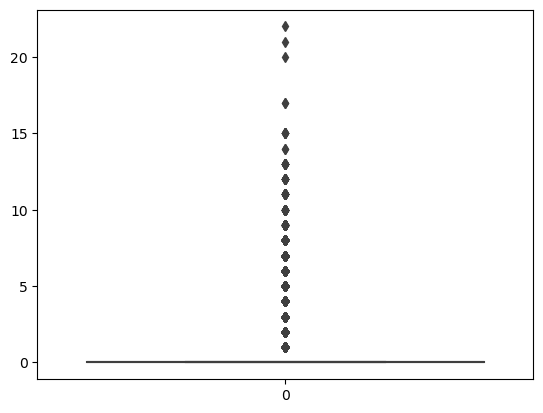

In [9]:
sns.boxplot(data["assists"])

In [10]:
data["assists"]=winsorize(data["assists"],limits=0.20)

<Axes: >

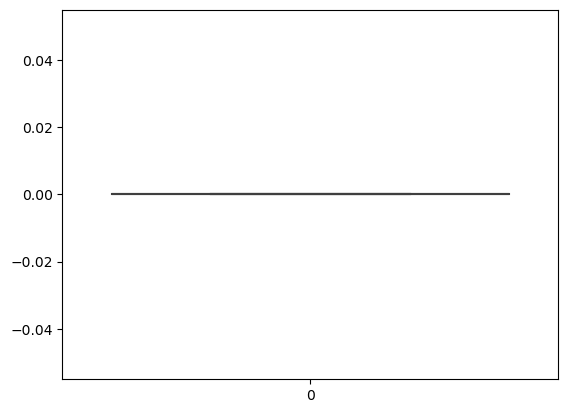

In [11]:
sns.boxplot(data["assists"])

<Axes: >

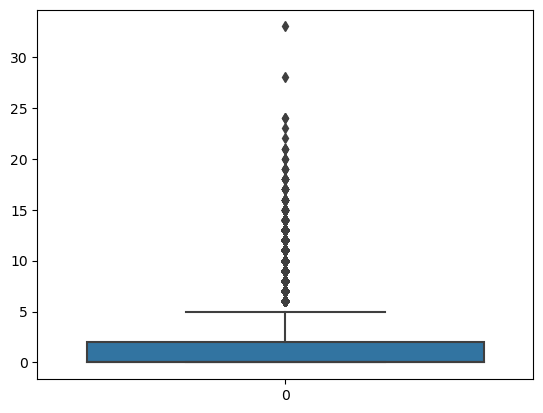

In [12]:
sns.boxplot(data["boosts"])

<Axes: >

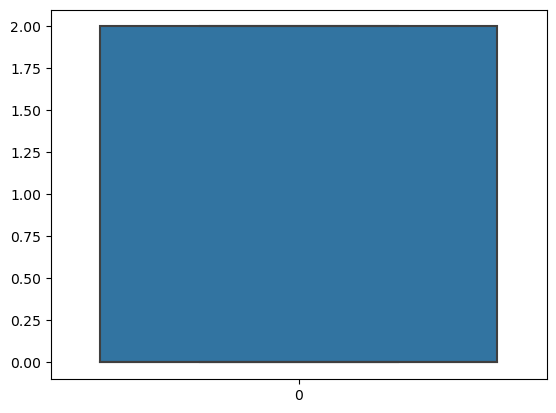

In [13]:
data["boosts"]=winsorize(data["boosts"],limits=0.20)
sns.boxplot(data["boosts"])

<Axes: >

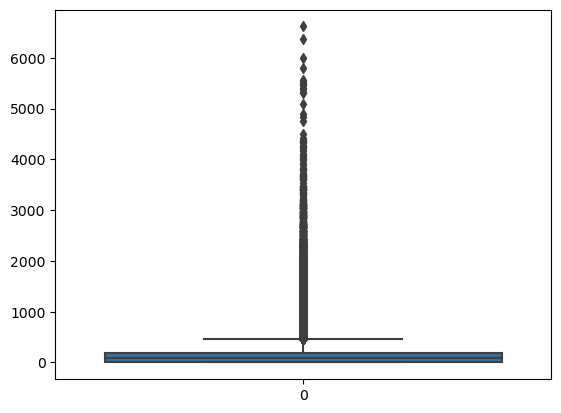

In [14]:
sns.boxplot(data["damageDealt"])

<Axes: >

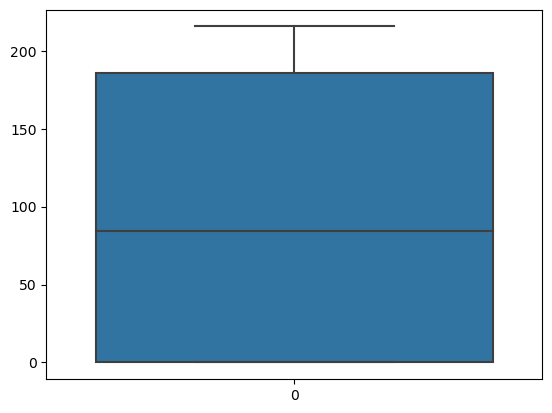

In [15]:
data["damageDealt"]=winsorize(data["damageDealt"],limits=0.20)
sns.boxplot(data["damageDealt"])

<Axes: >

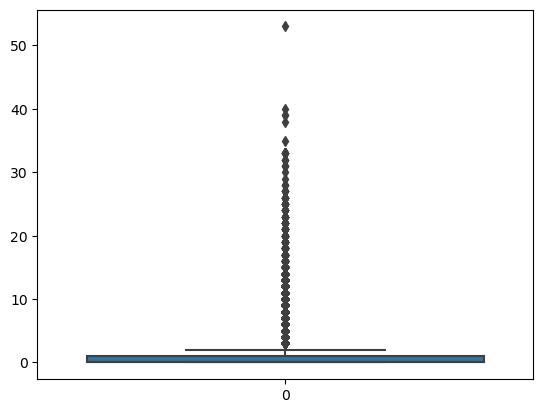

In [16]:
sns.boxplot(data["DBNOs"])

<Axes: >

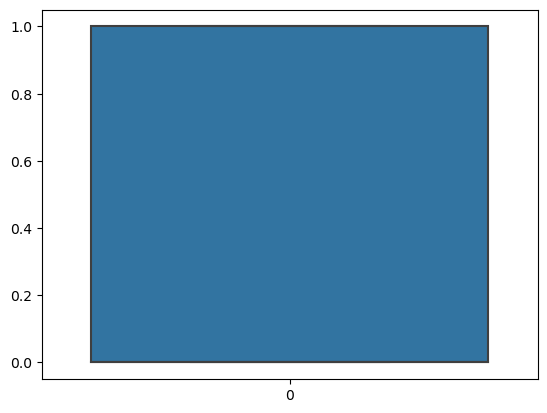

In [17]:
data["DBNOs"]=winsorize(data["DBNOs"],limits=0.20)
sns.boxplot(data["DBNOs"])

<Axes: >

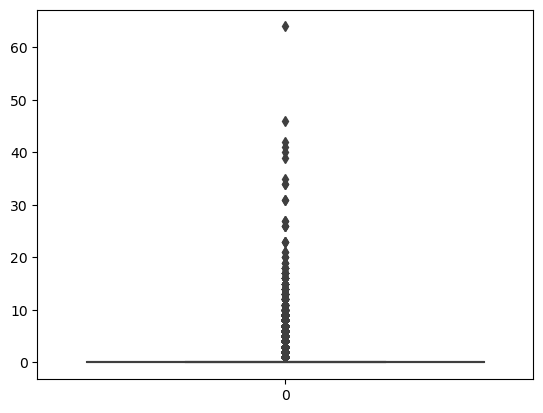

In [18]:
sns.boxplot(data["headshotKills"])

<Axes: >

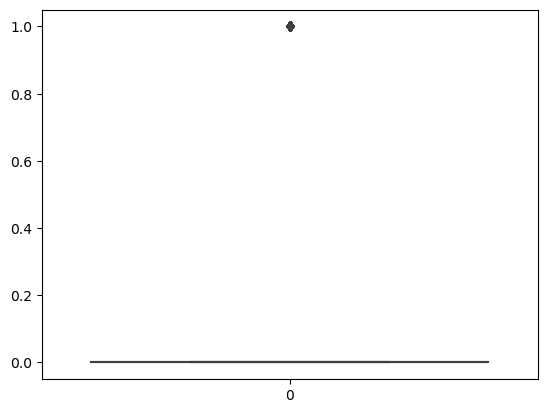

In [19]:
data["headshotKills"]=winsorize(data["headshotKills"],limits=0.05)
sns.boxplot(data["headshotKills"])

<Axes: >

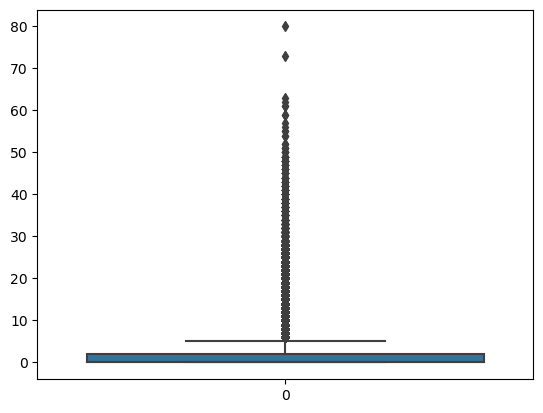

In [20]:
sns.boxplot(data["heals"])

<Axes: >

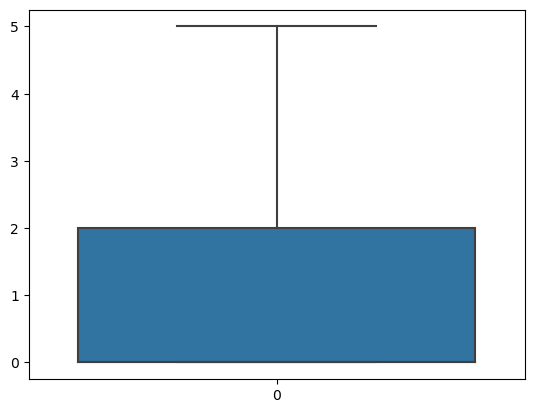

In [21]:
data["heals"]=winsorize(data["heals"],limits=0.10)
sns.boxplot(data["heals"])

<Axes: >

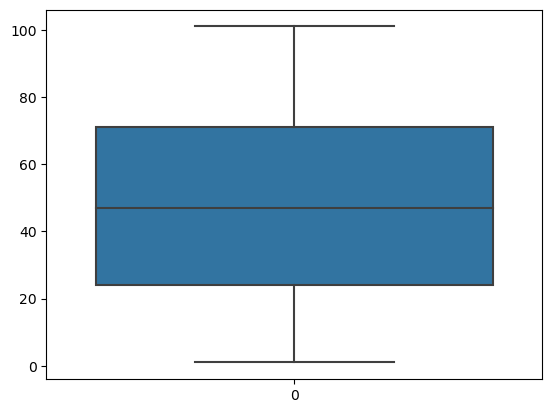

In [22]:
sns.boxplot(data["killPlace"])

<Axes: >

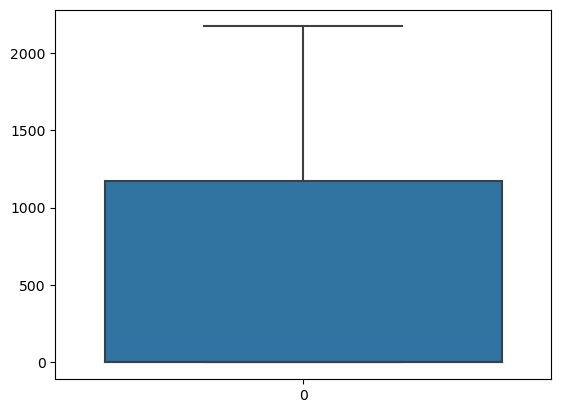

In [23]:
sns.boxplot(data["killPoints"])

<Axes: >

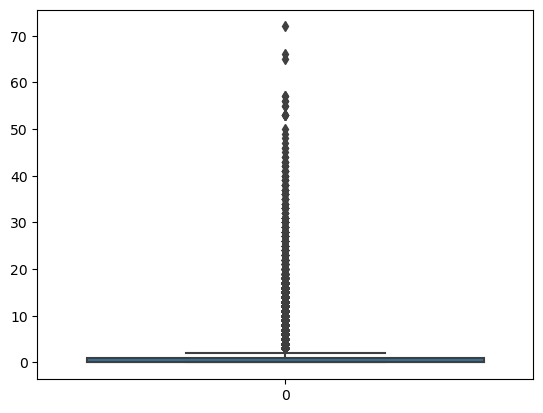

In [24]:
sns.boxplot(data["kills"])

<Axes: >

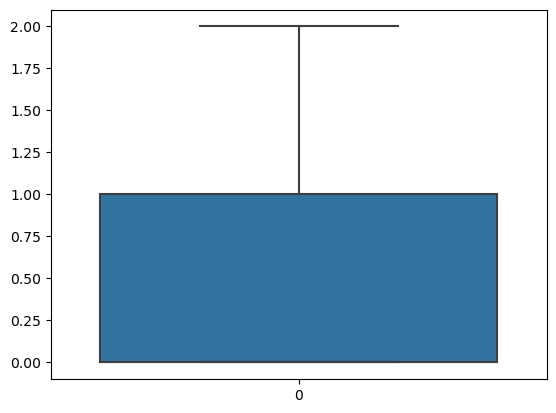

In [25]:
data["kills"]=winsorize(data["kills"],0.15)
sns.boxplot(data["kills"])

<Axes: >

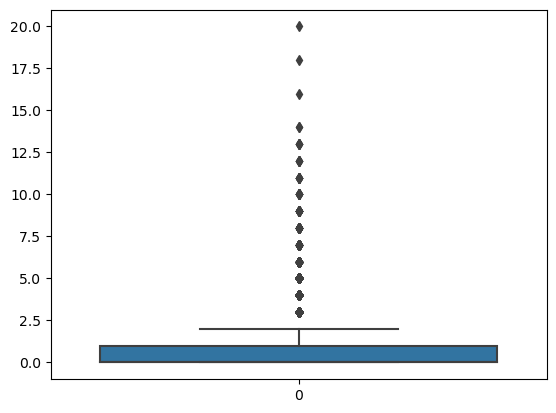

In [26]:
sns.boxplot(data["killStreaks"])

<Axes: >

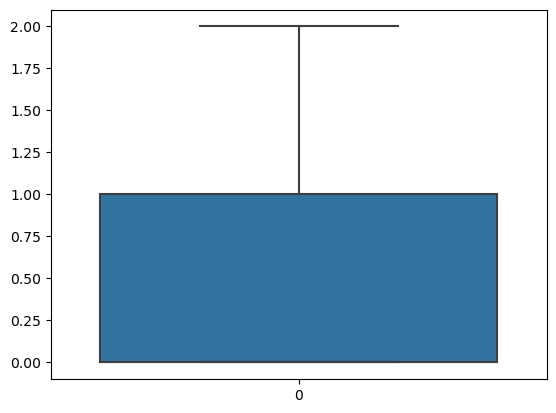

In [27]:
data["killStreaks"]=winsorize(data["killStreaks"],limits=0.05)
sns.boxplot(data["killStreaks"])

<Axes: >

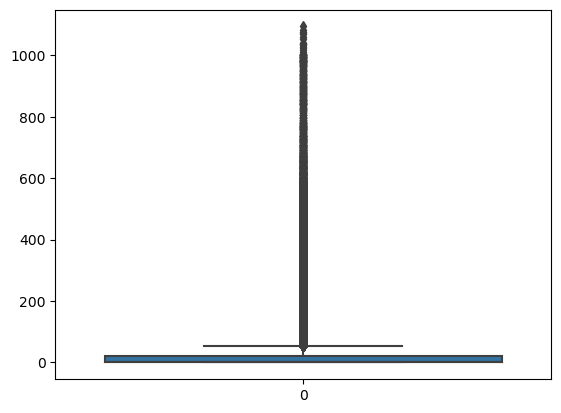

In [28]:
sns.boxplot(data["longestKill"])

<Axes: >

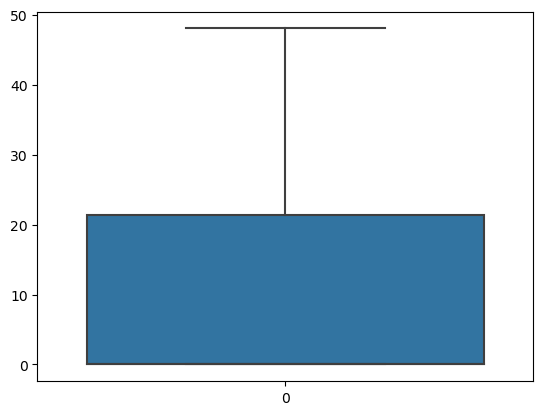

In [29]:
data["longestKill"]=winsorize(data["longestKill"],limits=0.15)
sns.boxplot(data["longestKill"])

<Axes: >

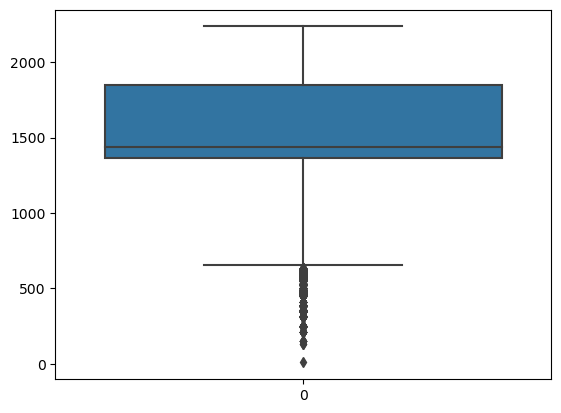

In [30]:
sns.boxplot(data["matchDuration"])

<Axes: >

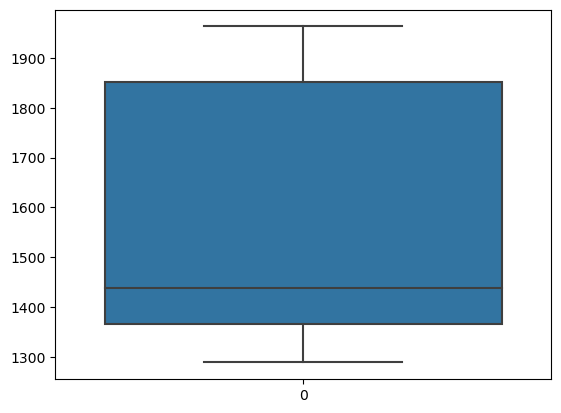

In [31]:
data["matchDuration"]=winsorize(data["matchDuration"],limits=0.05)
sns.boxplot(data["matchDuration"])

<Axes: >

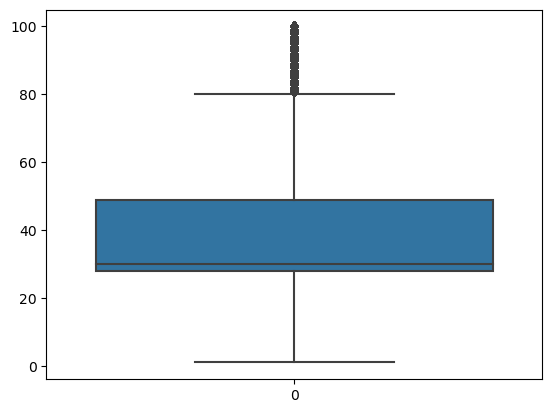

In [32]:
sns.boxplot(data["maxPlace"])

<Axes: >

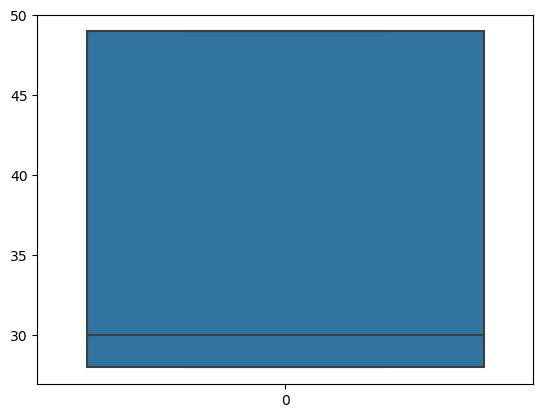

In [33]:
data["maxPlace"]=winsorize(data["maxPlace"],limits=0.20)
sns.boxplot(data["maxPlace"])

<Axes: >

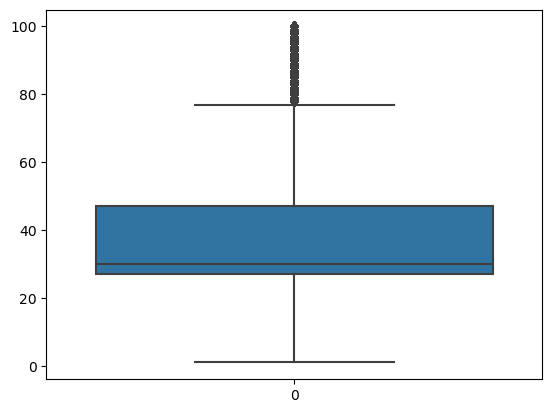

In [34]:
sns.boxplot(data["numGroups"])

<Axes: >

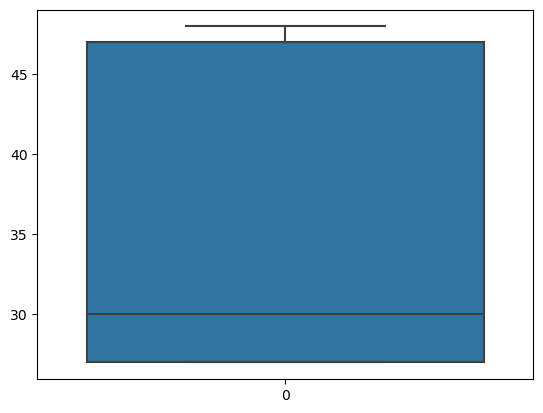

In [35]:
data["numGroups"]=winsorize(data["numGroups"],limits=0.20)
sns.boxplot(data["numGroups"])

<Axes: >

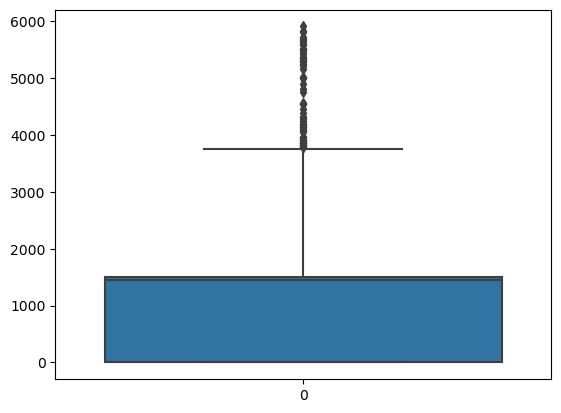

In [36]:
sns.boxplot(data["rankPoints"])

<Axes: >

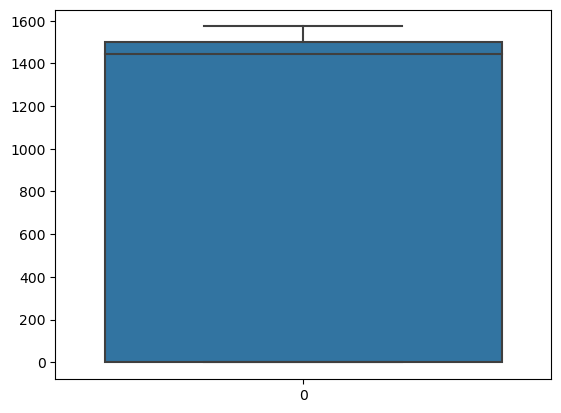

In [37]:
data["rankPoints"]=winsorize(data["rankPoints"],limits=0.05)
sns.boxplot(data["rankPoints"])

<Axes: >

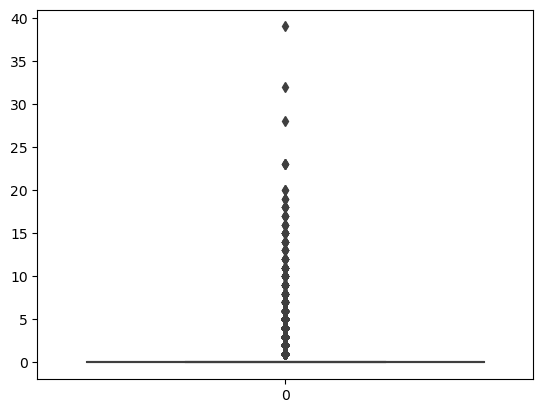

In [38]:
sns.boxplot(data["revives"])

<Axes: >

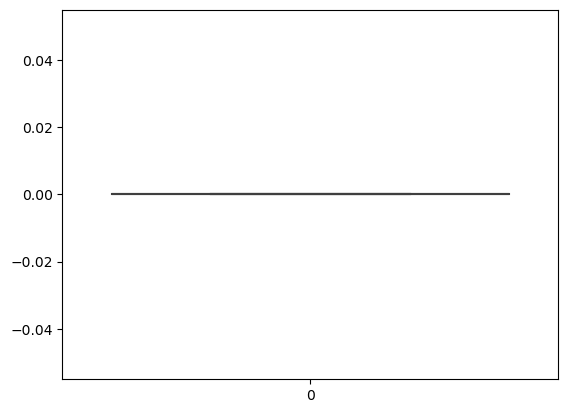

In [39]:
data["revives"]=winsorize(data["revives"],limits=0.15)
sns.boxplot(data["revives"])

<Axes: >

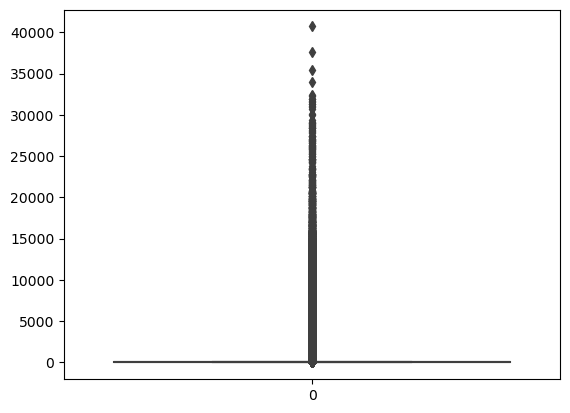

In [40]:
sns.boxplot(data["rideDistance"])

<Axes: >

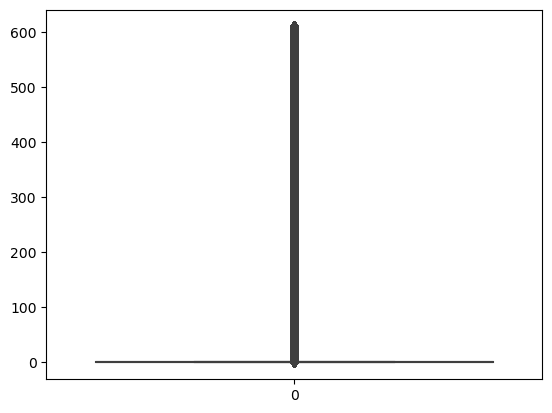

In [41]:
data["rideDistance"]=winsorize(data["rideDistance"],limits=0.20)
sns.boxplot(data["rideDistance"])

<Axes: >

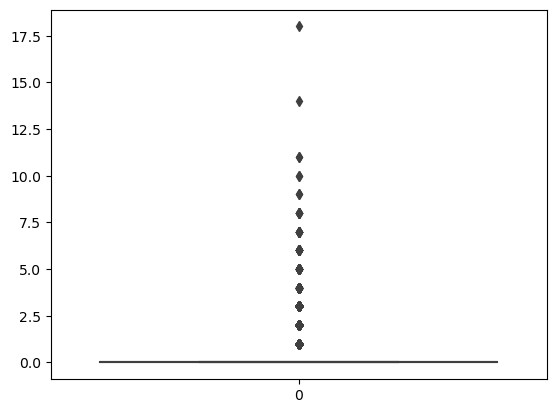

In [42]:
sns.boxplot(data["roadKills"])

<Axes: >

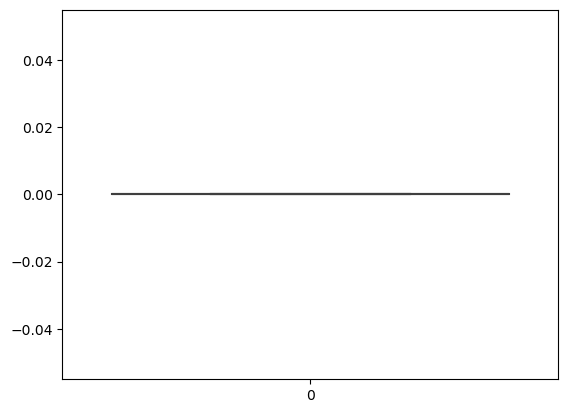

In [43]:
data["roadKills"]=winsorize(data["roadKills"],limits=0.05)
sns.boxplot(data["roadKills"])

<Axes: >

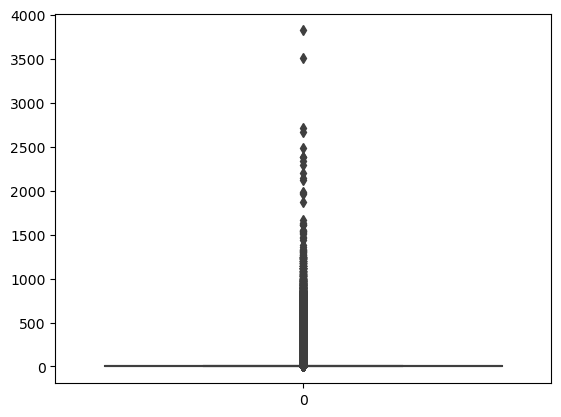

In [44]:
sns.boxplot(data["swimDistance"])

<Axes: >

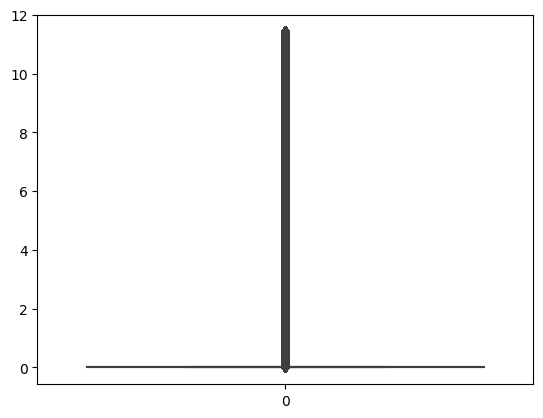

In [45]:
data["swimDistance"]=winsorize(data["swimDistance"],limits=0.05)
sns.boxplot(data["swimDistance"])

<Axes: >

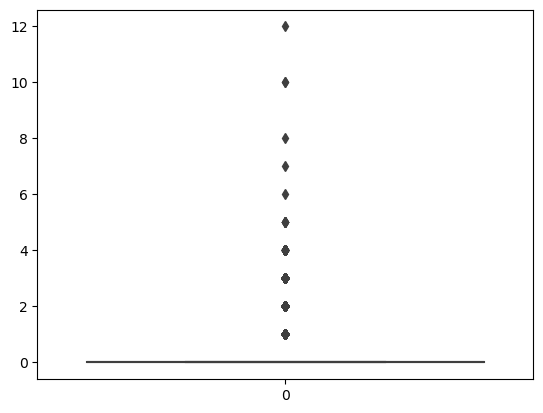

In [46]:
sns.boxplot(data["teamKills"])

<Axes: >

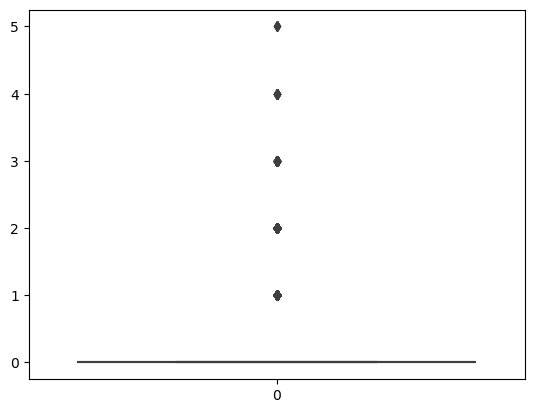

In [47]:
sns.boxplot(data["vehicleDestroys"])

<Axes: >

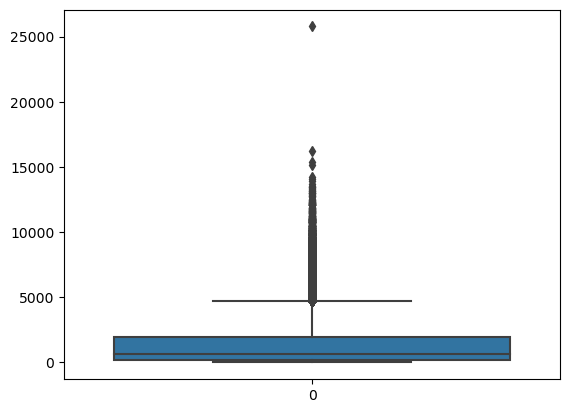

In [48]:
sns.boxplot(data["walkDistance"])

<Axes: >

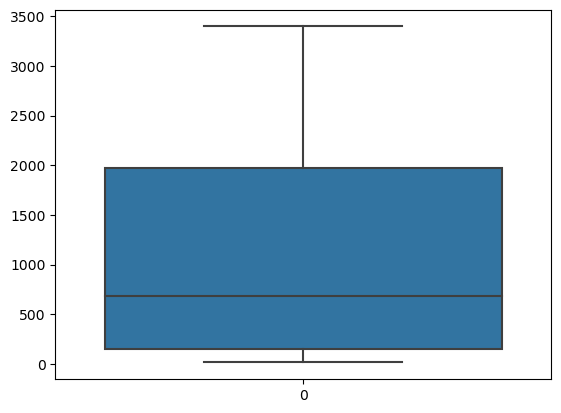

In [49]:
data["walkDistance"]=winsorize(data["walkDistance"],limits=0.05)
sns.boxplot(data["walkDistance"])

<Axes: >

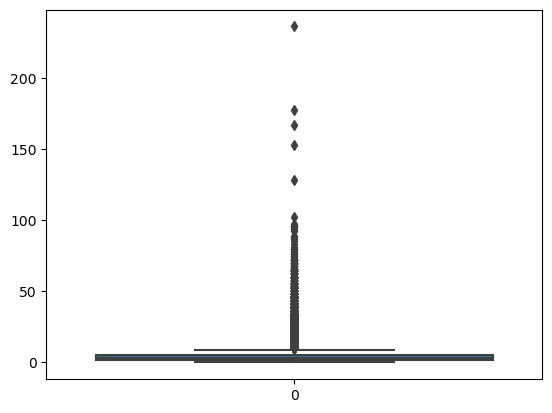

In [50]:
sns.boxplot(data["weaponsAcquired"])

<Axes: >

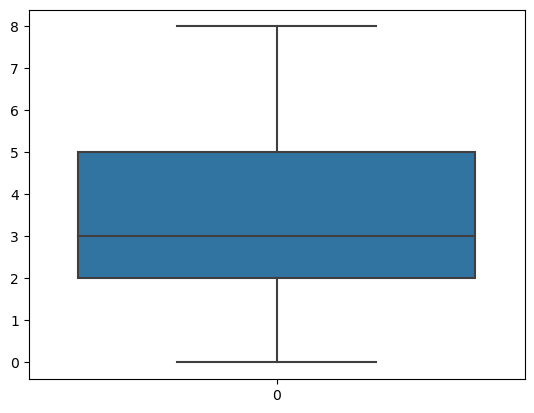

In [51]:
data["weaponsAcquired"]=winsorize(data["weaponsAcquired"],limits=0.05)
sns.boxplot(data["weaponsAcquired"])

<Axes: >

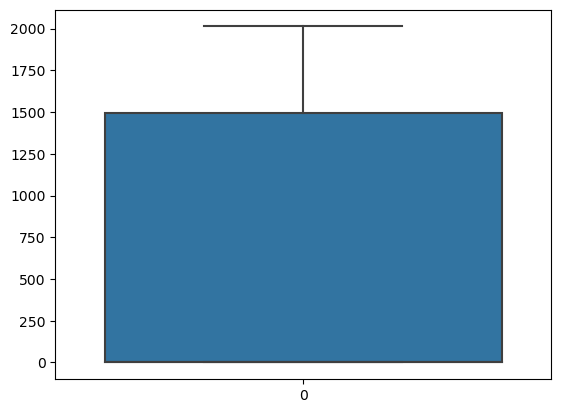

In [52]:
sns.boxplot(data["winPoints"])

<Axes: >

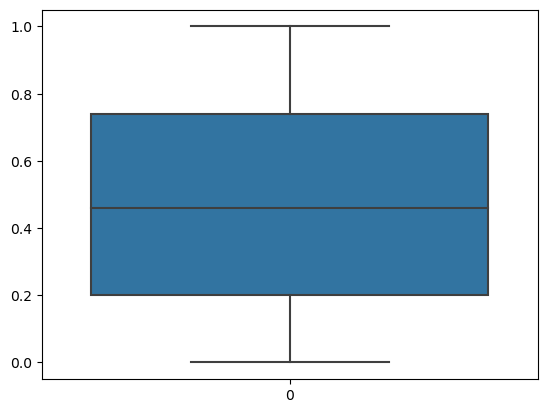

In [53]:
sns.boxplot(data["winPlacePerc"])

In [54]:
data

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.000,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.040,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,0,0,68.00,0,0,0,47,...,0,0.0000,0,0.000,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.000,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.000,0,0,49.75,2,0,0.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4446961,afff7f652dbc10,d238e426f50de7,18492834ce5635,0,0,0.00,0,0,0,74,...,0,610.6000,0,0.000,0,0,1019.00,3,1507,0.1786
4446962,f4197cf374e6c0,408cdb5c46b2ac,ee854b837376d9,0,1,44.15,0,0,0,69,...,0,0.0000,0,0.000,0,0,81.70,6,0,0.2935
4446963,e1948b1295c88a,e26ac84bdf7cef,6d0cd12784f1ab,0,0,59.06,0,0,0,66,...,0,0.0000,0,2.184,0,0,788.70,4,0,0.4815
4446964,cc032cdd73b7ac,c2223f35411394,c9c701d0ad758a,0,2,180.40,1,1,2,11,...,0,0.0000,0,0.000,0,0,2748.00,8,0,0.8000


In [55]:
data.count()

Id                 4446966
groupId            4446966
matchId            4446966
assists            4446966
boosts             4446966
damageDealt        4446966
DBNOs              4446966
headshotKills      4446966
heals              4446966
killPlace          4446966
killPoints         4446966
kills              4446966
killStreaks        4446966
longestKill        4446966
matchDuration      4446966
matchType          4446966
maxPlace           4446966
numGroups          4446966
rankPoints         4446966
revives            4446966
rideDistance       4446966
roadKills          4446966
swimDistance       4446966
teamKills          4446966
vehicleDestroys    4446966
walkDistance       4446966
weaponsAcquired    4446966
winPoints          4446966
winPlacePerc       4446965
dtype: int64

In [56]:
data=data.drop(columns=["Id","groupId","matchId"],axis=1)
data.head()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,0,0,0.00,0,0,0,60,1241,0,0,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,0,0,91.47,0,0,0,57,0,0,0,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,0,0,68.00,0,0,0,47,0,0,0,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,0,0,32.90,0,0,0,75,0,0,0,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,0,0,100.00,0,0,0,45,0,1,1,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


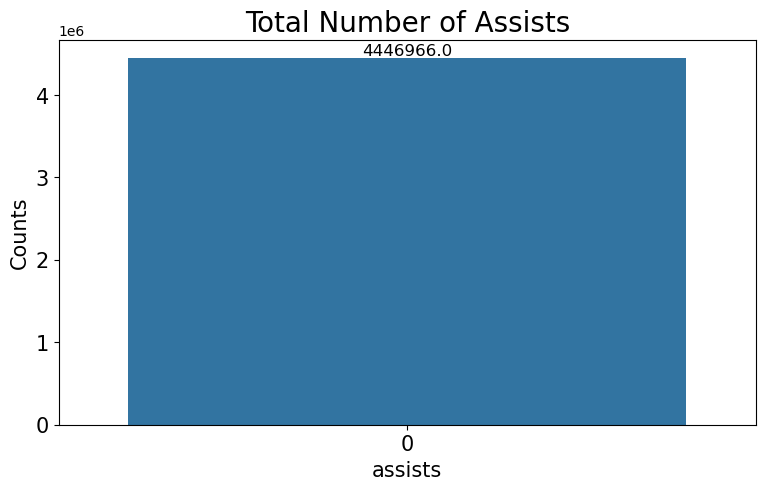

In [57]:
plt.figure(figsize=(9,5))
ax=sns.countplot(x='assists', data=data,)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=12)
plt.title("Total Number of Assists",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("assists",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

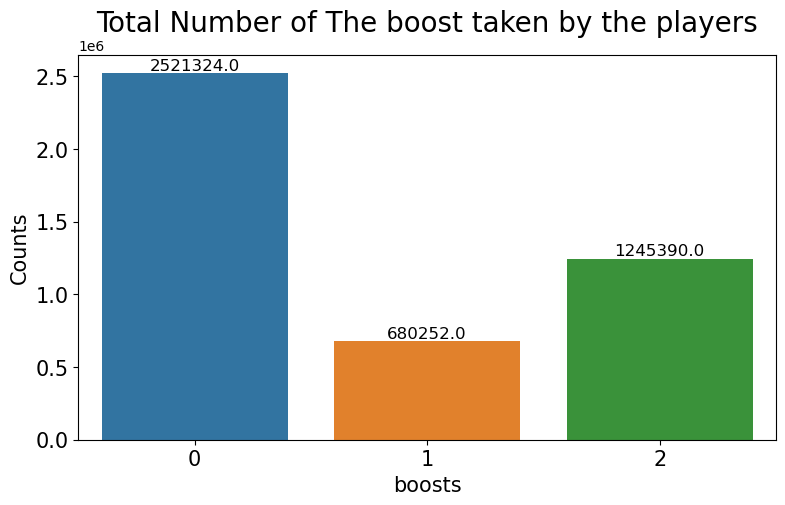

In [58]:
plt.figure(figsize=(9,5))
ax=sns.countplot(x='boosts', data=data,)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=12)
plt.title("Total Number of The boost taken by the players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("boosts",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

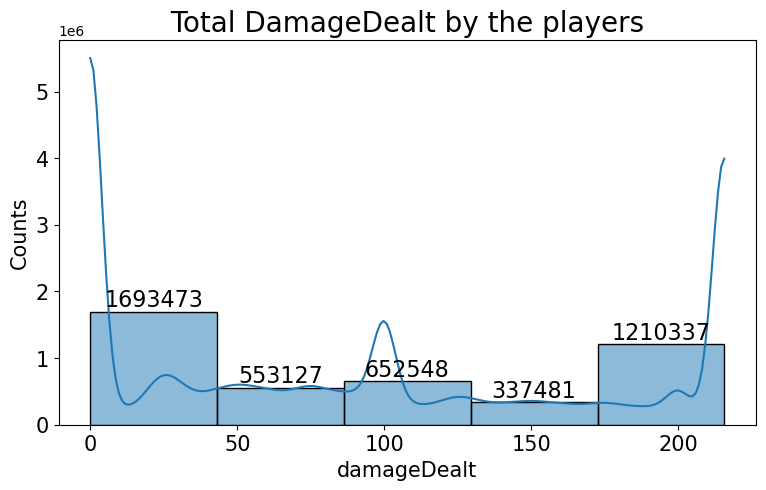

In [59]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='damageDealt', data=data,bins=5,kde=True)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title(" Total DamageDealt by the players ",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("damageDealt",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

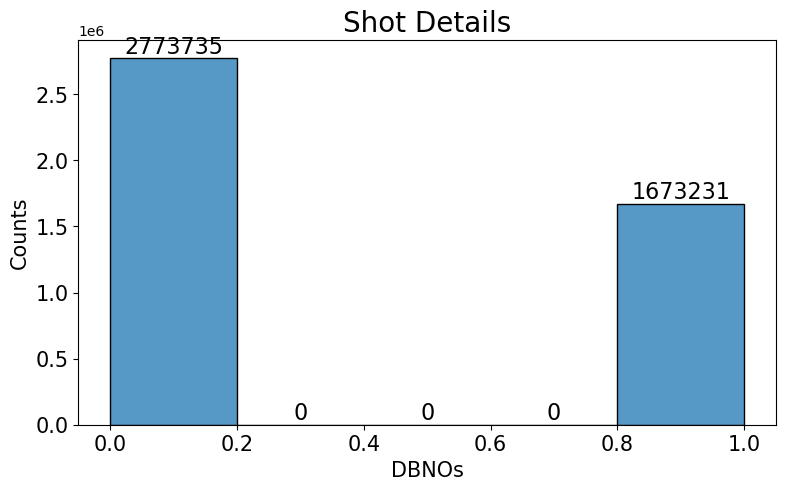

In [60]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='DBNOs', data=data,bins=5)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Shot Details",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("DBNOs",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

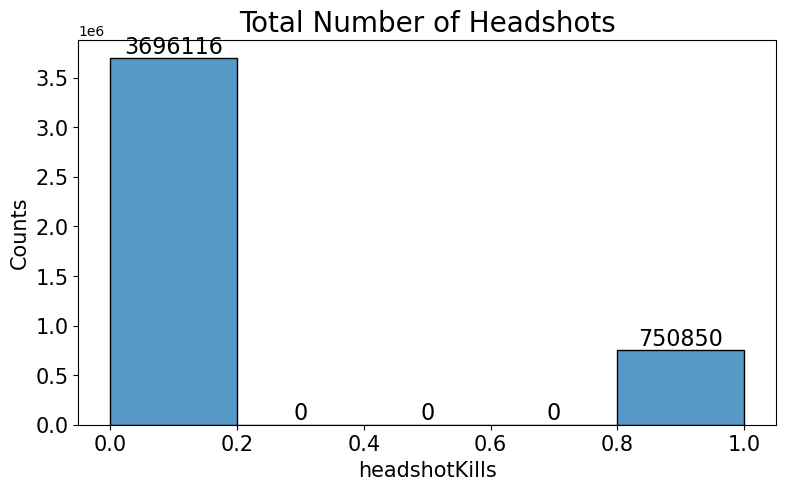

In [61]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='headshotKills', data=data,bins=5)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Total Number of Headshots",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("headshotKills",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

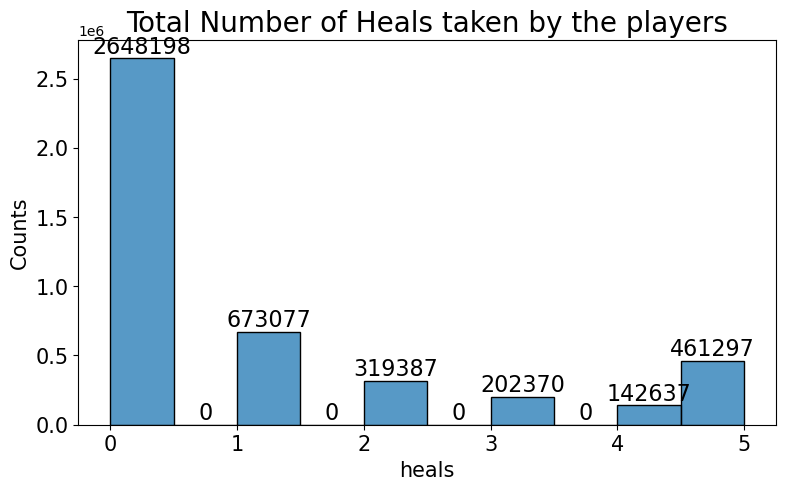

In [62]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='heals', data=data,bins=10)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Total Number of Heals taken by the players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("heals",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

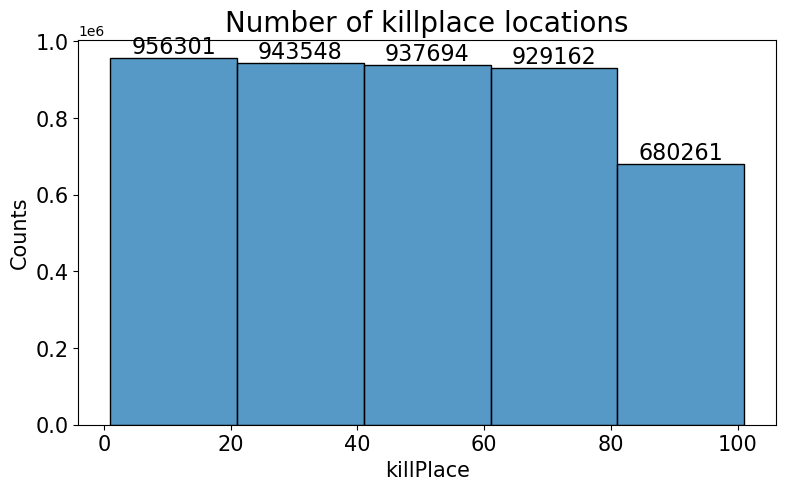

In [63]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='killPlace', data=data,bins=5)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Number of killplace locations",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("killPlace",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

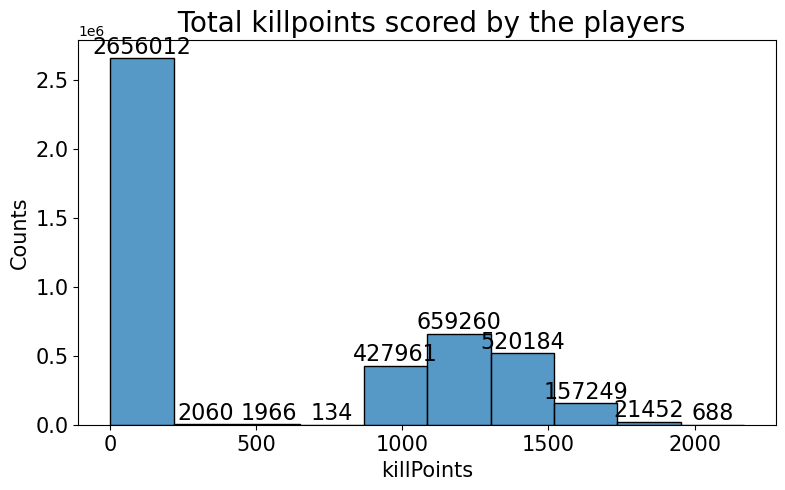

In [64]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='killPoints', data=data,bins=10)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title(" Total killpoints scored by the players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("killPoints",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

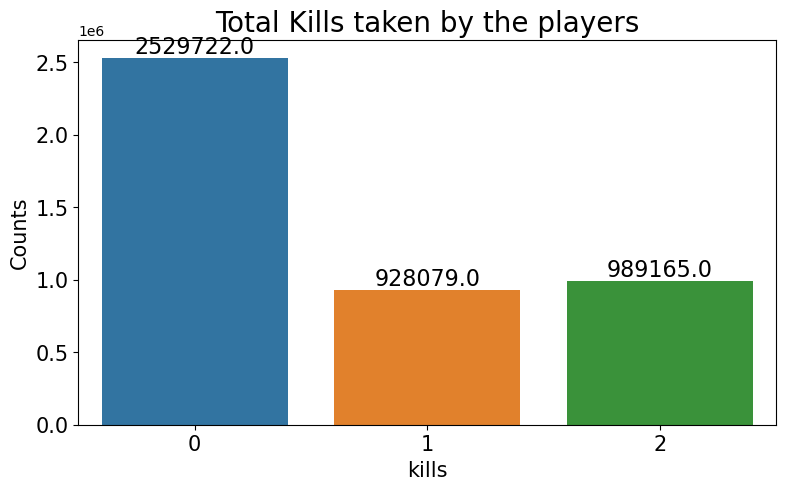

In [65]:
plt.figure(figsize=(9,5))
ax=sns.countplot(x='kills', data=data)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Total Kills taken by the players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("kills",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

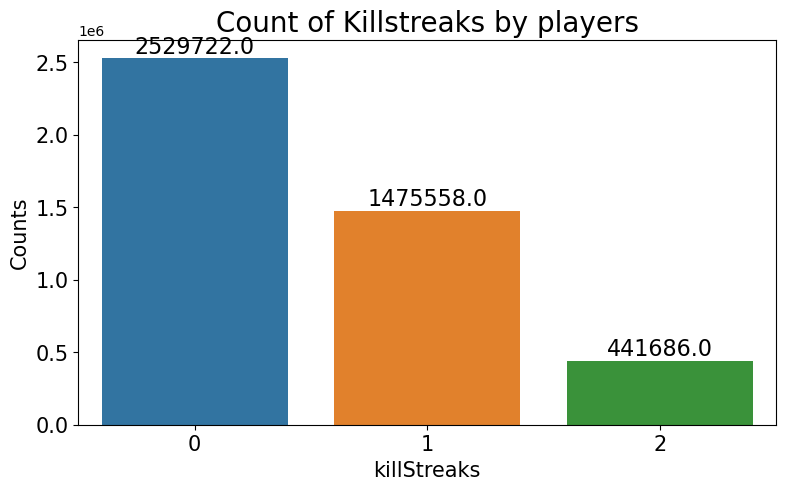

In [66]:
plt.figure(figsize=(9,5))
ax=sns.countplot(x='killStreaks', data=data)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Count of Killstreaks by players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("killStreaks",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

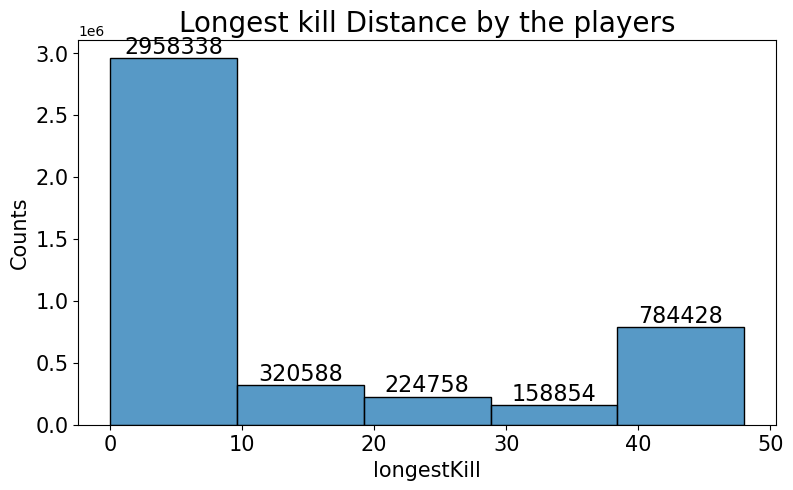

In [67]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='longestKill', data=data,bins=5)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Longest kill Distance by the players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("longestKill",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

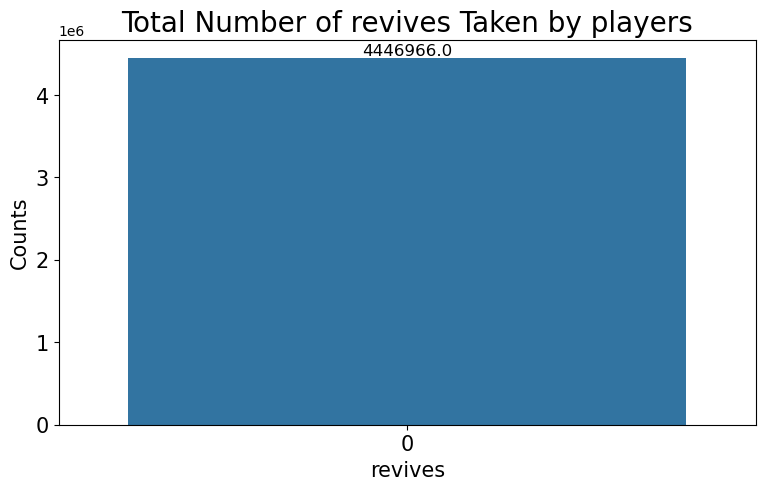

In [68]:
plt.figure(figsize=(9,5))
ax=sns.countplot(x='revives', data=data)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=12)
plt.title("Total Number of revives Taken by players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("revives",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

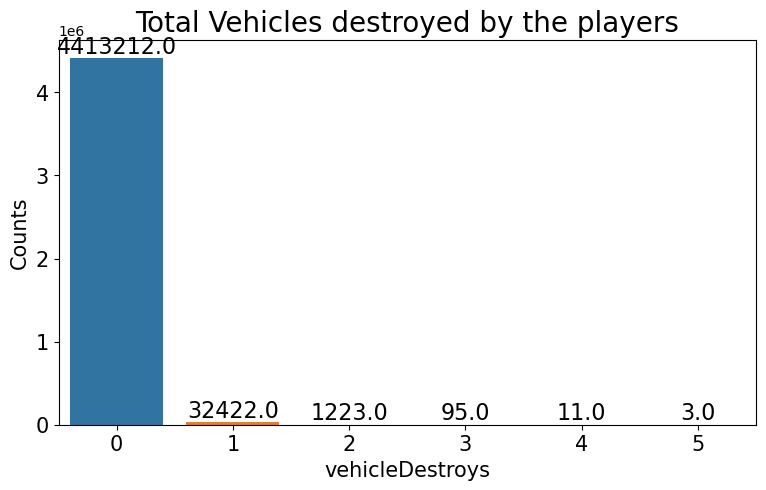

In [69]:
plt.figure(figsize=(9,5))
ax=sns.countplot(x='vehicleDestroys', data=data)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Total Vehicles destroyed by the players",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("vehicleDestroys",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

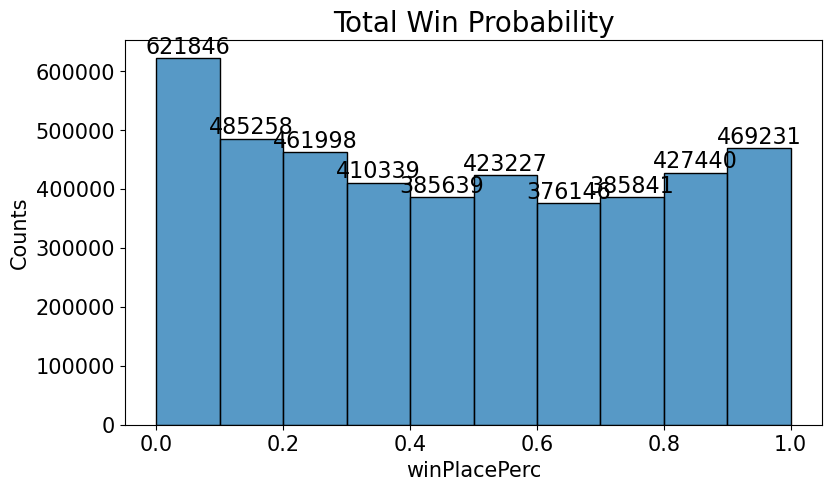

In [70]:
plt.figure(figsize=(9,5))
ax=sns.histplot(x='winPlacePerc', data=data,bins=10)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', color='black', fontsize=16)
plt.title("Total Win Probability",size=20)
plt.xticks(rotation=0,size=15)
plt.xlabel("winPlacePerc",size=15)
plt.ylabel("Counts",size=15)
plt.yticks(size=15)
plt.show()

In [71]:
data.count()

assists            4446966
boosts             4446966
damageDealt        4446966
DBNOs              4446966
headshotKills      4446966
heals              4446966
killPlace          4446966
killPoints         4446966
kills              4446966
killStreaks        4446966
longestKill        4446966
matchDuration      4446966
matchType          4446966
maxPlace           4446966
numGroups          4446966
rankPoints         4446966
revives            4446966
rideDistance       4446966
roadKills          4446966
swimDistance       4446966
teamKills          4446966
vehicleDestroys    4446966
walkDistance       4446966
weaponsAcquired    4446966
winPoints          4446966
winPlacePerc       4446965
dtype: int64

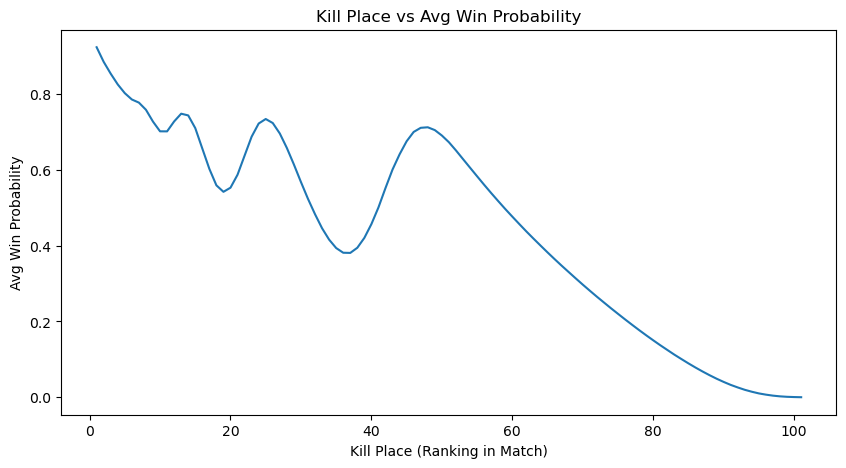

In [72]:
# Average winPlacePerc by killPlace
avg_killplace = data.groupby("killPlace")["winPlacePerc"].mean()

avg_killplace.plot(kind="line", figsize=(10,5))
plt.xlabel("Kill Place (Ranking in Match)")
plt.ylabel("Avg Win Probability")
plt.title("Kill Place vs Avg Win Probability")
plt.show()


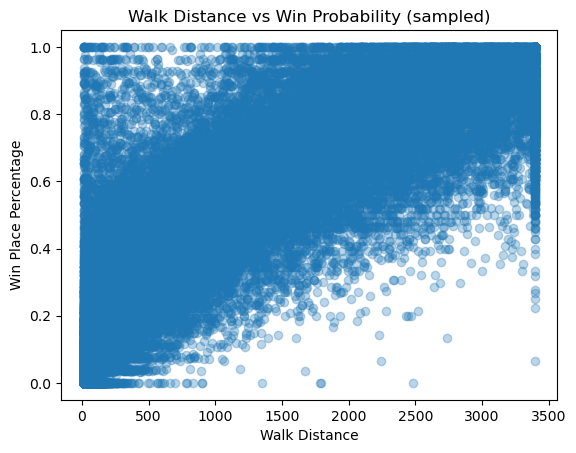

In [73]:
# Sample 50,000 rows for bivariate plots
df_sample = data.sample(n=50000, random_state=42)

import matplotlib.pyplot as plt

plt.scatter(df_sample["walkDistance"], df_sample["winPlacePerc"], alpha=0.3)
plt.xlabel("Walk Distance")
plt.ylabel("Win Place Percentage")
plt.title("Walk Distance vs Win Probability (sampled)")
plt.show()


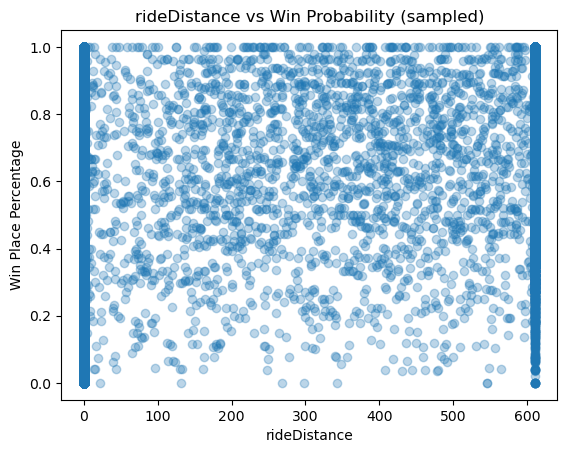

In [74]:
# Sample 50,000 rows for bivariate plots
df_sample = data.sample(n=50000, random_state=42)

import matplotlib.pyplot as plt

plt.scatter(df_sample["rideDistance"], df_sample["winPlacePerc"], alpha=0.3)
plt.xlabel("rideDistance")
plt.ylabel("Win Place Percentage")
plt.title("rideDistance vs Win Probability (sampled)")
plt.show()


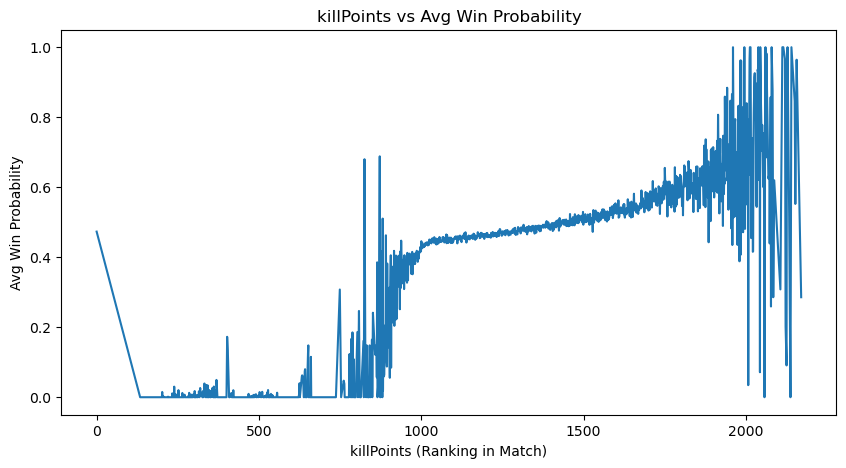

In [75]:
# Average winPlacePerc by killPlace
avg_killplace = data.groupby("killPoints")["winPlacePerc"].mean()

avg_killplace.plot(kind="line", figsize=(10,5))
plt.xlabel("killPoints (Ranking in Match)")
plt.ylabel("Avg Win Probability")
plt.title("killPoints vs Avg Win Probability")
plt.show()


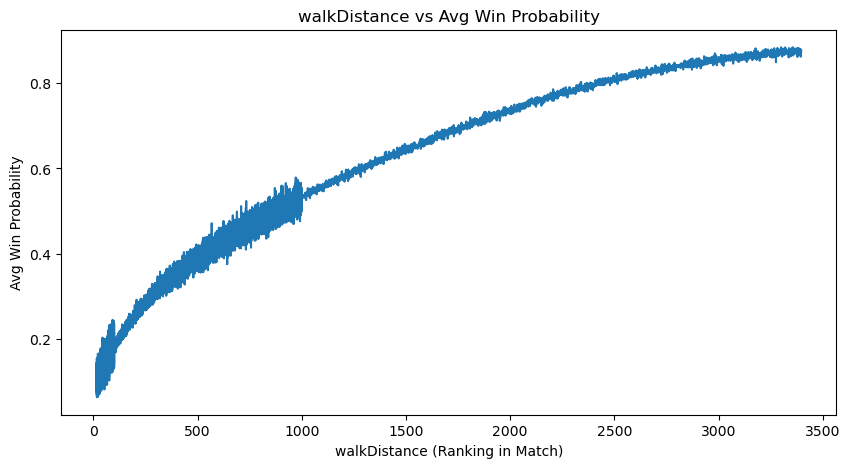

In [76]:
# Average winPlacePerc by killPlace
avg_killplace = data.groupby("walkDistance")["winPlacePerc"].mean()

avg_killplace.plot(kind="line", figsize=(10,5))
plt.xlabel("walkDistance (Ranking in Match)")
plt.ylabel("Avg Win Probability")
plt.title("walkDistance vs Avg Win Probability")
plt.show()


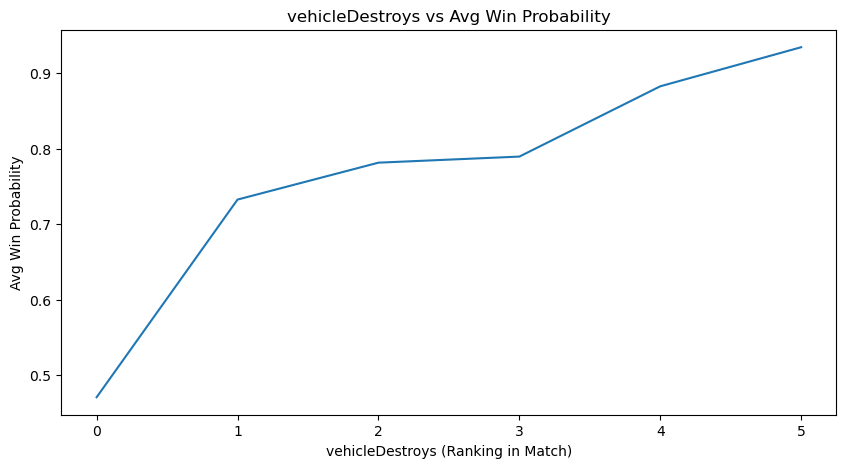

In [77]:
# Average winPlacePerc by killPlace
avg_killplace = data.groupby("vehicleDestroys")["winPlacePerc"].mean()

avg_killplace.plot(kind="line", figsize=(10,5))
plt.xlabel("vehicleDestroys (Ranking in Match)")
plt.ylabel("Avg Win Probability")
plt.title("vehicleDestroys vs Avg Win Probability")
plt.show()


In [78]:
data.isnull().sum()

assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

In [79]:
# Fill missing winPlacePerc with mean
mean_winperc = data["winPlacePerc"].mean()
data["winPlacePerc"] = data["winPlacePerc"].fillna(mean_winperc)

print("Missing winPlacePerc after fill:", data["winPlacePerc"].isna().sum())


Missing winPlacePerc after fill: 0


In [80]:
# data = pd.get_dummies(data, drop_first=True)

In [81]:
data.count()

assists            4446966
boosts             4446966
damageDealt        4446966
DBNOs              4446966
headshotKills      4446966
heals              4446966
killPlace          4446966
killPoints         4446966
kills              4446966
killStreaks        4446966
longestKill        4446966
matchDuration      4446966
matchType          4446966
maxPlace           4446966
numGroups          4446966
rankPoints         4446966
revives            4446966
rideDistance       4446966
roadKills          4446966
swimDistance       4446966
teamKills          4446966
vehicleDestroys    4446966
walkDistance       4446966
weaponsAcquired    4446966
winPoints          4446966
winPlacePerc       4446966
dtype: int64

In [82]:
data = pd.get_dummies(data, drop_first=True)

In [83]:
data.head()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,matchType_normal-duo,matchType_normal-duo-fpp,matchType_normal-solo,matchType_normal-solo-fpp,matchType_normal-squad,matchType_normal-squad-fpp,matchType_solo,matchType_solo-fpp,matchType_squad,matchType_squad-fpp
0,0,0,0.00,0,0,0,60,1241,0,0,...,False,False,False,False,False,False,False,False,False,True
1,0,0,91.47,0,0,0,57,0,0,0,...,False,False,False,False,False,False,False,False,False,True
2,0,0,68.00,0,0,0,47,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,0,0,32.90,0,0,0,75,0,0,0,...,False,False,False,False,False,False,False,False,False,True
4,0,0,100.00,0,0,0,45,0,1,1,...,False,False,False,False,False,False,False,True,False,False


In [84]:
# Separate features and target
X = data.drop(columns=["winPlacePerc"])
y = data["winPlacePerc"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (3557572, 39)  Test shape: (889394, 39)


In [85]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline: predict mean winPlacePerc
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())

print("Baseline Model Performance:")
print("MAE:", mean_absolute_error(y_test, mean_pred))
print("RMSE:", mean_squared_error(y_test, mean_pred, squared=False))
print("R²:", r2_score(y_test, mean_pred))


Baseline Model Performance:
MAE: 0.26787424976306634
RMSE: 0.307352600862229
R²: -7.117398053146928e-07


In [86]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=2.0, random_state=42)
ridge.fit(X_train, y_train)

preds_ridge = ridge.predict(X_test)

print("Ridge Regression Performance:")
print("MAE:", mean_absolute_error(y_test, preds_ridge))
print("RMSE:", mean_squared_error(y_test, preds_ridge, squared=False))
print("R²:", r2_score(y_test, preds_ridge))


Ridge Regression Performance:
MAE: 0.08276413569686895
RMSE: 0.1131373758471084
R²: 0.8645001773810069


In [87]:
X_train_sample = X_train.sample(100000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,   # reduce number of trees
    max_depth=15,      # shallower trees
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_sample, y_train_sample)

RandomForestRegressor(max_depth=15, n_estimators=50, n_jobs=-1, random_state=42)

In [88]:
predsample_rf = rf.predict(X_test)

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predsample_rf)
rmse = mean_squared_error(y_test,predsample_rf , squared=False)
r2 = r2_score(y_test,predsample_rf)

print("Random Forest Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


Random Forest Performance:
MAE: 0.06529317556603088
RMSE: 0.09283047033945191
R²: 0.9087763120359434


In [90]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,    # fewer trees
    learning_rate=0.1,
    max_depth=3,         # shallow trees
    subsample=0.5,       # faster training
    random_state=42
)

gbr.fit(X_train_sample, y_train_sample)
y_pred_gbr = gbr.predict(X_test)
y_pred_gbr

array([0.44967762, 0.49507518, 0.82462972, ..., 0.02204525, 0.29624704,
       0.82930616])

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = mean_squared_error(y_test, y_pred_gbr, squared=False)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Performance:")
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R²:", r2_gbr)


Gradient Boosting Performance:
MAE: 0.07094369545399044
RMSE: 0.0999144834755244
R²: 0.894322283804439


# Model Comparison Report – PUBG Win Probability Prediction
## Evaluation Metrics Used
### - MAE (Mean Absolute Error): Average absolute difference between predictions and actual values. Lower is better.
### - RMSE (Root Mean Squared Error): Penalizes larger errors more. Lower is better.
### - R² (Coefficient of Determination): Explains variance captured by the model. Closer to 1 means better fit.

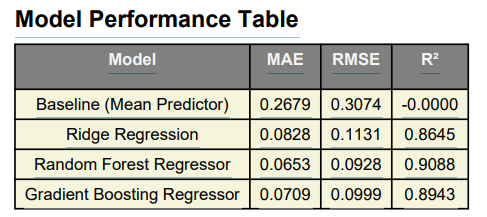

# Observations
## 1. Baseline Model performed very poorly (R² ≈ 0). This confirms that just predicting the mean win percentage is not useful.
## 2. Ridge Regression significantly improved performance (R² ≈ 0.86), showing linear models can capture good trends.
## 3. Random Forest delivered the best performance overall:
### - Lowest MAE (0.0653) and RMSE (0.0928)
### - Highest R² (0.909), meaning it explained ~91% of the variance.
## 4. Gradient Boosting also performed strongly (R² ≈ 0.894), slightly behind Random Forest, but still much better than Ridge.
# Final Recommendation
### - Random Forest is the best model for production use in this dataset, as it provides the most accurate predictions with a strong balance of bias-variance.
### - Gradient Boosting is also a good alternative if interpretability and feature importance visualization are needed.
### - Ridge Regression is faster and simpler,

# ⚡ Challenges and Solutions Report

# 1. Large Dataset
## Challenge: The dataset was very large, making analysis and training slow.
## Solution:
### - Used random sampling to work with smaller subsets.
### - Applied parallel processing (n_jobs=-1) to speed up training.
### - Reduced model complexity (fewer trees, smaller depth).

# 2. Missing Values
## Challenge: Some features (like winPlacePerc, distance variables) had missing values.
## Solution:
### - Filled missing numerical values with mean.
### - Filled missing categorical values with mode.

# 3. Categorical Variables
## Challenge: The column matchType was non-numeric.
## Solution: Applied One-Hot Encoding to convert categories into numbers.

# 4. Irrelevant Features
## Challenge: Columns like Id, groupId, and matchId do not help in prediction.
## Solution: Dropped these columns before training.

# 5. Model Training Time
## Challenge: Random Forest and Gradient Boosting models took too long to train.
## Solution:
### - Trained on a subset of 100,000 rows.
### - Adjusted parameters to reduce complexity.

# 6. Model Comparison
## Challenge: Needed to find the best model.
## Solution: Compared models using MAE, RMSE, and R².
### Result: Random Forest performed the best with the highest accuracy.

## ✅ Final Note: After handling missing data, encoding, and sampling,
### Random Forest emerged as the most reliable model for predicting PUBG win probability.
